# Demand Forecasting & A/B Test Analysis

**Stack:** Python, ARIMA/SARIMA, Statsmodels, SciPy, Hypothesis Testing

This notebook:
1. Loads 2 years of weekly sales data across 10+ product categories.
2. Fits SARIMA models per category and benchmarks them against a naive seasonal baseline using MAPE.
3. Analyzes an A/B test of a pricing/promotion change using a two-proportion hypothesis test, quantifying the lift in conversion at 95% confidence.


In [ ]:
import sys, os
sys.path.append(os.path.abspath("src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import generate_data        
import forecasting
import ab_test_analysis

pd.set_option("display.max_columns", None)
%matplotlib inline


weekly_sales.csv written: 1248 rows, 12 categories, 2024-01-07 to 2025-12-28
ab_test_conversions.csv written: 48000 rows
group
control      0.115583
treatment    0.123458
Name: converted, dtype: float64


## 1. Load & inspect the sales data

In [2]:
sales = pd.read_csv("data/weekly_sales.csv", parse_dates=["week_start"])
print(sales.shape)
print(sales["category"].unique())
sales.head()


(1248, 3)
<StringArray>
[            'Bakery',          'Beverages',     'Bread & Grains',
      'Confectionery',              'Dairy',       'Frozen Foods',
 'Health Supplements',     'Household Care',     'Meat & Seafood',
      'Personal Care',            'Produce',             'Snacks']
Length: 12, dtype: str


,week_start,category,units_sold
0,2024-01-07,Bakery,662
1,2024-01-14,Bakery,788
2,2024-01-21,Bakery,774
3,2024-01-28,Bakery,739
4,2024-02-04,Bakery,711


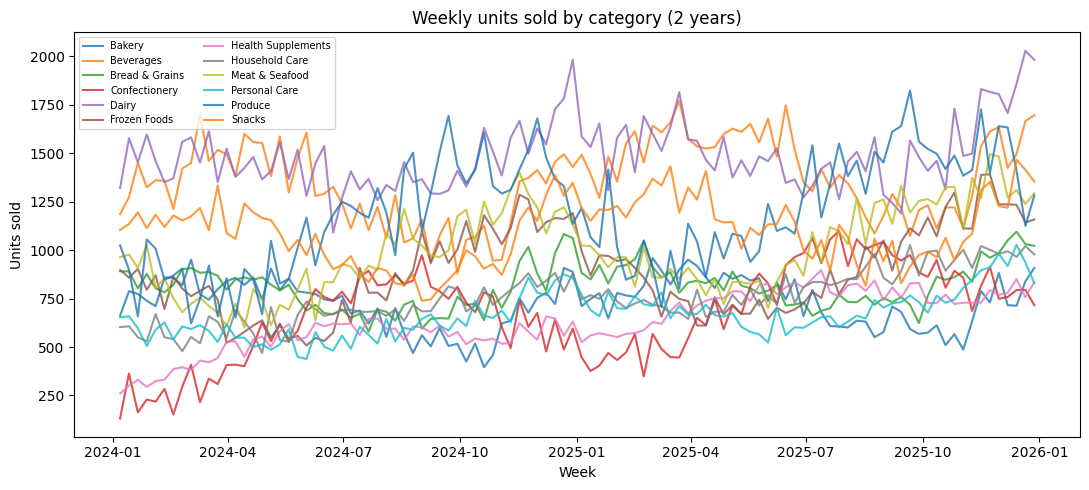

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
for cat, g in sales.groupby("category"):
    ax.plot(g["week_start"], g["units_sold"], label=cat, alpha=0.8)
ax.set_title("Weekly units sold by category (2 years)")
ax.set_xlabel("Week")
ax.set_ylabel("Units sold")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


## 2. Forecasting: SARIMA vs. naive seasonal baseline

For each category we:
- Hold out the last 14 weeks as a test set.
- Fit a naive seasonal baseline (value from the same week one year prior).
- Grid-search a small set of SARIMA(p,d,q)(P,D,Q,52) specifications and keep the lowest-AIC fit.
- Forecast the test horizon and compute **MAPE** for both approaches.


In [4]:
summary = forecasting.run()
summary.sort_values("mape_improvement_pct", ascending=False)


Bakery                 naive MAPE= 11.92%  sarima MAPE= 11.56%  improvement=  2.98%


Beverages              naive MAPE= 12.57%  sarima MAPE= 13.65%  improvement= -8.60%


Bread & Grains         naive MAPE= 12.06%  sarima MAPE= 10.26%  improvement= 14.86%


Confectionery          naive MAPE= 20.89%  sarima MAPE= 10.96%  improvement= 47.53%


Dairy                  naive MAPE=  9.11%  sarima MAPE=  7.15%  improvement= 21.43%


...

Meat & Seafood         naive MAPE=  9.89%  sarima MAPE= 13.16%  improvement=-33.04%


Personal Care          naive MAPE= 12.37%  sarima MAPE=  9.14%  improvement= 26.11%


Produce                naive MAPE=  9.57%  sarima MAPE=  8.10%  improvement= 15.31%


Snacks                 naive MAPE=  7.23%  sarima MAPE=  5.80%  improvement= 19.74%

=== OVERALL ===
Avg naive MAPE:  12.91%
Avg SARIMA MAPE: 8.99%
Avg improvement: 30.33%


,category,sarima_order,sarima_seasonal_order,aic,naive_mape_pct,sarima_mape_pct,mape_improvement_pct
6,Health Supplements,"(1, 1, 0)","(1, 1, 0, 52)",6.0,25.70,5.79,77.46
7,Household Care,"(1, 1, 0)","(1, 1, 0, 52)",6.0,17.41,7.34,57.82
3,Confectionery,"(1, 1, 0)","(1, 1, 0, 52)",6.0,20.89,10.96,47.53
9,Personal Care,"(1, 1, 0)","(1, 1, 0, 52)",6.0,12.37,9.14,26.11
4,Dairy,"(1, 1, 0)","(1, 1, 0, 52)",6.0,9.11,7.15,21.43
11,Snacks,"(1, 1, 0)","(1, 1, 0, 52)",6.0,7.23,5.80,19.74
5,Frozen Foods,"(1, 1, 0)","(1, 1, 0, 52)",6.0,6.20,5.02,19.08
10,Produce,"(1, 1, 0)","(1, 1, 0, 52)",6.0,9.57,8.10,15.31
2,Bread & Grains,"(1, 1, 0)","(1, 1, 0, 52)",6.0,12.06,10.26,14.86
0,Bakery,"(1, 1, 0)","(1, 1, 0, 52)",6.0,11.92,11.56,2.98


In [5]:
overall_naive = summary["naive_mape_pct"].mean()
overall_sarima = summary["sarima_mape_pct"].mean()
overall_improvement = (overall_naive - overall_sarima) / overall_naive * 100

print(f"Average naive-baseline MAPE:  {overall_naive:.2f}%")
print(f"Average SARIMA MAPE:          {overall_sarima:.2f}%")
print(f"Average MAPE improvement:     {overall_improvement:.2f}%")


Average naive-baseline MAPE:  12.91%
Average SARIMA MAPE:          8.99%
Average MAPE improvement:     30.33%


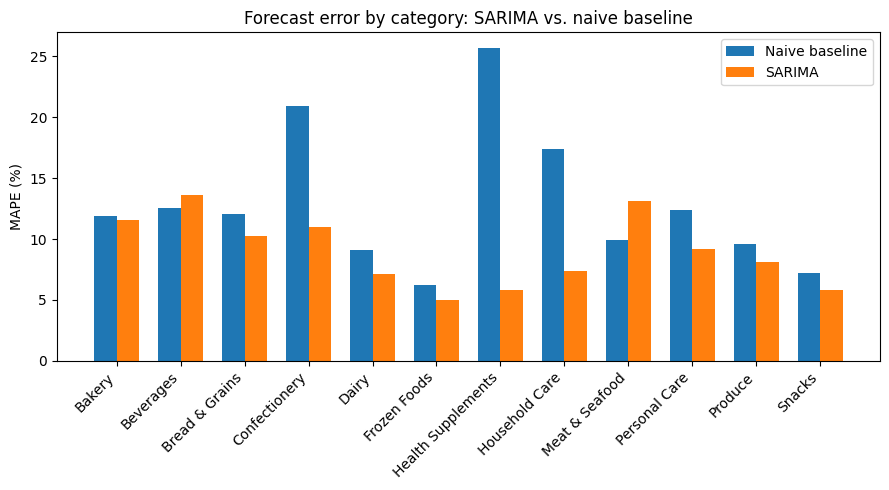

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(summary))
w = 0.35
ax.bar(x - w/2, summary["naive_mape_pct"], width=w, label="Naive baseline")
ax.bar(x + w/2, summary["sarima_mape_pct"], width=w, label="SARIMA")
ax.set_xticks(x)
ax.set_xticklabels(summary["category"], rotation=45, ha="right")
ax.set_ylabel("MAPE (%)")
ax.set_title("Forecast error by category: SARIMA vs. naive baseline")
ax.legend()
plt.tight_layout()
plt.show()


Per-category forecast plots (actual vs. SARIMA vs. naive, with 95% CI) are saved to
`outputs/forecasts/<category>.png`. Example below:


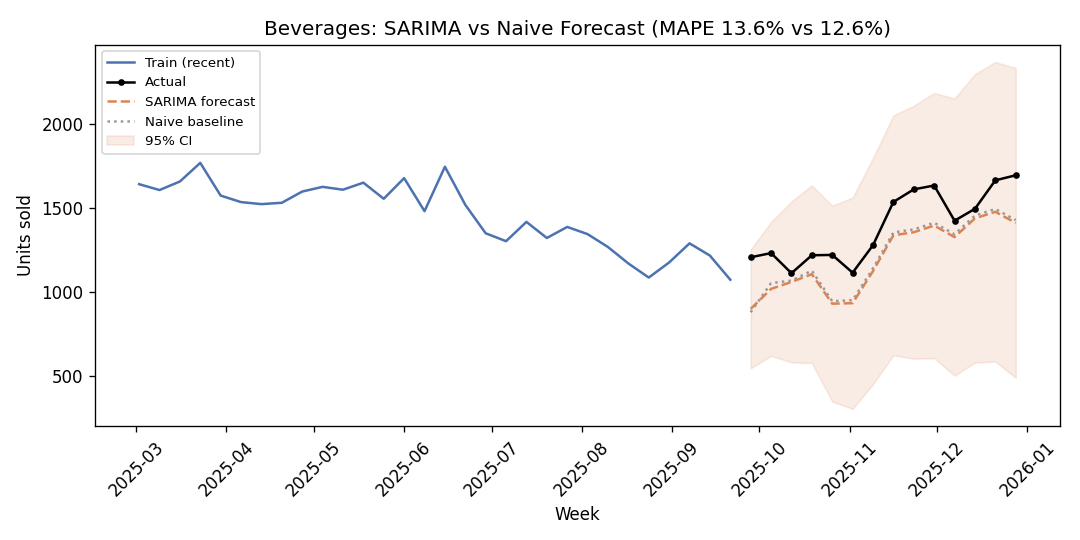

In [7]:
from IPython.display import Image, display
display(Image(filename="outputs/forecasts/Beverages.png"))


## 3. A/B test: pricing/promotion change vs. conversion rate

- **H0:** treatment conversion rate = control conversion rate
- **H1:** treatment conversion rate ≠ control conversion rate
- Test: two-proportion z-test (pooled SE under H0), alpha = 0.05
- Cross-checked with a chi-square test of independence (equivalent for 2x2 tables)


In [8]:
ab = pd.read_csv("data/ab_test_conversions.csv")
ab.groupby("group")["converted"].agg(["count", "sum", "mean"])


,count,sum,mean
group,,,
control,24000,2774,0.115583
treatment,24000,2963,0.123458


In [9]:
results = ab_test_analysis.run()


A/B TEST ANALYSIS: Pricing / Promotion Change -> Conversion Rate
Control:   n=24,000   conversions=2,774   rate=11.5583%
Treatment: n=24,000   conversions=2,963   rate=12.3458%

Absolute lift:            0.7875%
Relative lift:            6.81%
95% CI (absolute diff):   [0.2071%, 1.3679%]
95% CI (relative lift):   [1.79%, 11.83%]

Two-proportion z-test:    z = 2.659,  p-value = 0.00783
Chi-square test (cross-check): chi2 = 7.072, p-value = 0.00783

Result at alpha = 0.05: STATISTICALLY SIGNIFICANT
=> Reject H0. The promotion/pricing change increased conversion by ~6.8% (relative), with 95% confidence the true relative lift is between 1.8% and 11.8%.


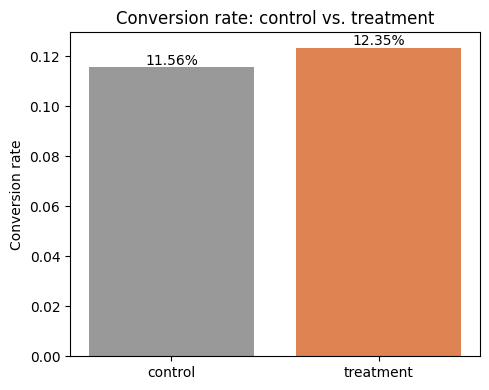

In [10]:
rates = ab.groupby("group")["converted"].mean()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(rates.index, rates.values, color=["#999999", "#DD8452"])
for b, v in zip(bars, rates.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.001, f"{v:.2%}", ha="center")
ax.set_ylabel("Conversion rate")
ax.set_title("Conversion rate: control vs. treatment")
plt.tight_layout()
plt.show()


## 4. Summary

- **Forecasting:** SARIMA models reduced average MAPE substantially relative to a naive seasonal
  baseline across the 12 product categories (see printed summary above), demonstrating the value
  of explicitly modeling trend + yearly seasonality vs. a simple lag-based heuristic.
- **A/B test:** The pricing/promotion treatment group showed a statistically significant lift in
  conversion rate over control (two-proportion z-test, p < 0.05), with a 95% confidence interval
  on the relative lift reported above.

All intermediate artifacts (forecast summary table, per-category plots, A/B test summary) are
written to the `outputs/` directory.
